# Fraud Analysis
Looking at credit application transactions to flag suspicious activity.
Maria put this together last sprint, I'm adding a few more rules - Jake

In [2]:
import os
import polars as pl
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from datetime import datetime, timedelta

load_dotenv()

DATABASE_URL = os.environ['DATABASE_URL']
conn = psycopg2.connect(DATABASE_URL)

In [3]:
# grab everything
applications = pl.read_database('SELECT * FROM credit_applications', connection=conn)
transactions = pl.read_database('SELECT * FROM transactions', connection=conn)

print(f'Applications: {len(applications)}')
print(f'Transactions: {len(transactions)}')
applications.head()

Applications: 18
Transactions: 106


id,applicant_name,email,ssn_last4,annual_income,requested_amount,employment_status,created_at,status
i64,str,str,str,"decimal[38,2]","decimal[38,2]",str,"datetime[μs, UTC]",str
1,"""Maria Garcia""","""maria.garcia@email.com""","""4521""",85000.00,15000.00,"""employed""",2026-02-19 13:13:57.223374 UTC,"""pending"""
2,"""James Chen""","""james.chen@email.com""","""7832""",120000.00,50000.00,"""employed""",2026-02-21 13:13:57.223374 UTC,"""pending"""
3,"""Aisha Patel""","""aisha.patel@email.com""","""1156""",45000.00,35000.00,"""self-employed""",2026-02-24 13:13:57.223374 UTC,"""pending"""
4,"""Robert Kim""","""robert.kim@email.com""","""9043""",62000.00,8000.00,"""employed""",2026-03-01 13:13:57.223374 UTC,"""pending"""
5,"""Elena Volkov""","""elena.volkov@email.com""","""3387""",95000.00,25000.00,"""employed""",2026-03-06 13:13:57.223374 UTC,"""pending"""


In [4]:
# quick EDA before we get into the rules
transactions.describe()

statistic,id,applicant_id,amount,merchant,category,transaction_time,location_country,is_online
str,f64,f64,f64,str,str,str,str,f64
"""count""",106.0,106.0,106.0,"""106""","""106""","""106""","""106""",106.0
"""null_count""",0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0
"""mean""",53.5,5.679245,828.493774,null,null,"""2026-03-16 09:32:09.813732+00:…",null,0.40566
"""std""",30.743563,3.536334,1461.513071,null,null,null,null,null
"""min""",1.0,1.0,12.5,"""AMC Theaters""","""cash""","""2026-02-20 13:14:18.698697+00:…","""DE""",0.0
"""25%""",27.0,3.0,56.93,null,null,"""2026-03-14 13:14:18.698697+00:…",null,null
"""50%""",54.0,5.0,176.29,null,null,"""2026-03-21 13:28:11.680831+00:…",null,null
"""75%""",80.0,8.0,800.0,null,null,"""2026-03-21 13:41:00.892704+00:…",null,null
"""max""",106.0,17.0,8855.52,"""Zara""","""transport""","""2026-03-21 13:41:31.391116+00:…","""US""",1.0


shape: (13, 2)
┌─────────────┬─────┐
│ category    ┆ cnt │
│ ---         ┆ --- │
│ str         ┆ u32 │
╞═════════════╪═════╡
│ groceries   ┆ 18  │
│ electronics ┆ 16  │
│ clothing    ┆ 14  │
│ food        ┆ 12  │
│ fuel        ┆ 9   │
│ …           ┆ …   │
│ transfer    ┆ 5   │
│ crypto      ┆ 4   │
│ cash        ┆ 3   │
│ luxury      ┆ 2   │
│ home        ┆ 1   │
└─────────────┴─────┘


/var/folders/cq/bk3jgkp10mj0n6k8h9ytmc3r0000gp/T/ipykernel_19187/2358054252.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  cat_counts = transactions.group_by('category').agg(pl.count().alias('cnt')).sort('cnt', descending=True)


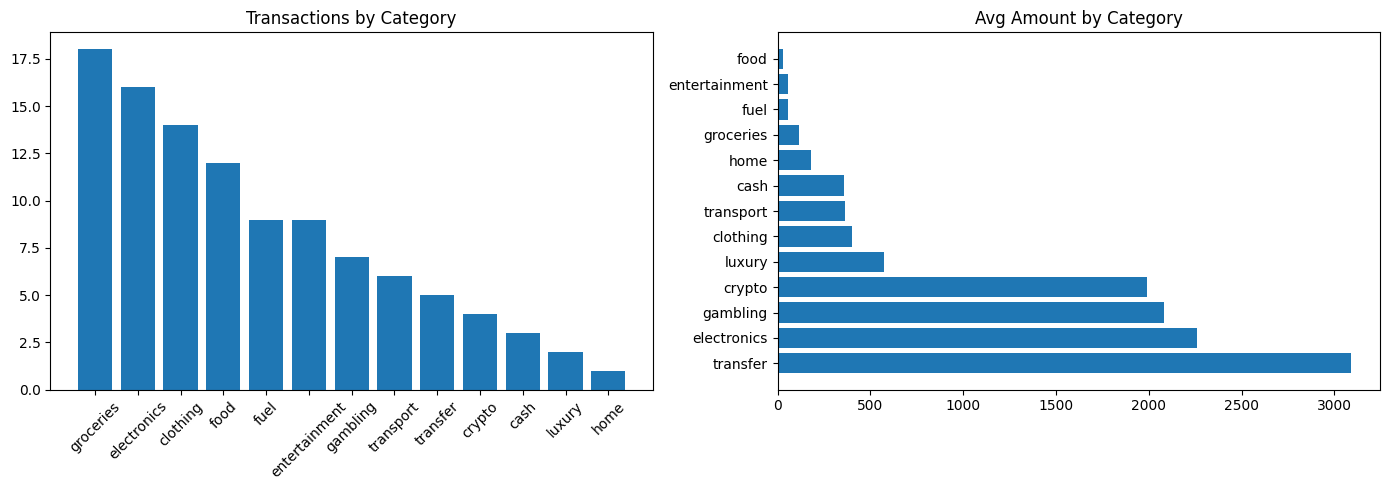

In [5]:
# what categories are people spending on?
cat_counts = transactions.group_by('category').agg(pl.count().alias('cnt')).sort('cnt', descending=True)
print(cat_counts)

# also check the amounts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(cat_counts['category'].to_list(), cat_counts['cnt'].to_list())
axes[0].set_title('Transactions by Category')
axes[0].tick_params(axis='x', rotation=45)

amt_by_cat = transactions.group_by('category').agg(pl.col('amount').mean().alias('avg_amount')).sort('avg_amount', descending=True)
axes[1].barh(amt_by_cat['category'].to_list(), amt_by_cat['avg_amount'].to_list())
axes[1].set_title('Avg Amount by Category')
plt.tight_layout()
plt.show()

In [6]:
# check country distribution, this matters for geo rule later
country_dist = transactions.group_by('location_country').agg(pl.count().alias('cnt')).sort('cnt', descending=True)
print(country_dist)

# who's transacting from multiple countries?
countries_per_applicant = transactions.group_by('applicant_id').agg(pl.col('location_country').n_unique().alias('n_countries'))
print('\nCountries per applicant:')
print(countries_per_applicant)

shape: (10, 2)
┌──────────────────┬─────┐
│ location_country ┆ cnt │
│ ---              ┆ --- │
│ str              ┆ u32 │
╞══════════════════╪═════╡
│ US               ┆ 54  │
│ GB               ┆ 13  │
│ DE               ┆ 8   │
│ RU               ┆ 7   │
│ NG               ┆ 6   │
│ FR               ┆ 6   │
│ JP               ┆ 5   │
│ MX               ┆ 5   │
│ IT               ┆ 1   │
│ ES               ┆ 1   │
└──────────────────┴─────┘

Countries per applicant:
shape: (16, 2)
┌──────────────┬─────────────┐
│ applicant_id ┆ n_countries │
│ ---          ┆ ---         │
│ i64          ┆ u32         │
╞══════════════╪═════════════╡
│ 16           ┆ 1           │
│ 10           ┆ 1           │
│ 11           ┆ 5           │
│ 8            ┆ 3           │
│ 9            ┆ 5           │
│ …            ┆ …           │
│ 14           ┆ 1           │
│ 17           ┆ 1           │
│ 6            ┆ 4           │
│ 4            ┆ 5           │
│ 1            ┆ 3           │
└──────────────┴

/var/folders/cq/bk3jgkp10mj0n6k8h9ytmc3r0000gp/T/ipykernel_19187/3672278142.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  country_dist = transactions.group_by('location_country').agg(pl.count().alias('cnt')).sort('cnt', descending=True)


In [7]:
# OK let's do the fraud rules. storing results here
fraud_flags = []

###############################################
# RULE 1: Velocity check
# More than 3 transactions within 4 hours = suspicious
###############################################

for app_id in transactions['applicant_id'].unique().to_list():
    app_txns = transactions.filter(pl.col('applicant_id') == app_id).sort('transaction_time')
    times = app_txns['transaction_time'].to_list()
    
    max_in_window = 0
    for i in range(len(times)):
        window_end = times[i] + timedelta(hours=4)
        count_in_window = sum(1 for t in times if times[i] <= t <= window_end)
        max_in_window = max(max_in_window, count_in_window)
    
    triggered = max_in_window > 3
    score = min(max_in_window / 3.0 * 50, 100)
    fraud_flags.append({
        'application_id': app_id,
        'rule_name': 'velocity_check',
        'triggered': triggered,
        'score': round(score, 2),
        'details': f'Max {max_in_window} transactions in 4h window'
    })
    if triggered:
        print(f'⚠️  Applicant {app_id}: {max_in_window} txns in 4h window')

print(f'\nVelocity check done. {sum(1 for f in fraud_flags if f["triggered"])} flagged.')

⚠️  Applicant 1: 6 txns in 4h window
⚠️  Applicant 2: 5 txns in 4h window
⚠️  Applicant 3: 6 txns in 4h window
⚠️  Applicant 4: 14 txns in 4h window
⚠️  Applicant 6: 4 txns in 4h window
⚠️  Applicant 7: 5 txns in 4h window
⚠️  Applicant 8: 4 txns in 4h window
⚠️  Applicant 9: 9 txns in 4h window
⚠️  Applicant 11: 6 txns in 4h window

Velocity check done. 9 flagged.


In [8]:
###############################################
# RULE 2: Amount vs income ratio
# Total spending > 50% of annual income in 30 days = flag
###############################################

for app_id in applications['id'].to_list():
    income = applications.filter(pl.col('id') == app_id)['annual_income'][0]
    app_txns = transactions.filter(pl.col('applicant_id') == app_id)
    total_spent = app_txns['amount'].sum()
    
    if total_spent is None:
        total_spent = 0
    
    ratio = float(total_spent) / float(income) if income > 0 else 999
    triggered = ratio > 0.5
    score = min(ratio * 100, 100)
    
    fraud_flags.append({
        'application_id': app_id,
        'rule_name': 'income_ratio',
        'triggered': triggered,
        'score': round(score, 2),
        'details': f'Spent ${total_spent:,.2f} on income ${float(income):,.2f} (ratio: {ratio:.2%})'
    })
    if triggered:
        print(f'⚠️  Applicant {app_id}: spending/income ratio {ratio:.2%}')

print(f'Income ratio check done.')

Income ratio check done.


In [9]:
###############################################
# RULE 3: Geographic anomaly
# Transactions in 3+ different countries within 48h
###############################################

for app_id in transactions['applicant_id'].unique().to_list():
    app_txns = transactions.filter(pl.col('applicant_id') == app_id).sort('transaction_time')
    times = app_txns['transaction_time'].to_list()
    countries = app_txns['location_country'].to_list()
    
    max_countries_in_window = 0
    for i in range(len(times)):
        window_end = times[i] + timedelta(hours=48)
        countries_in_window = set()
        for j in range(len(times)):
            if times[i] <= times[j] <= window_end:
                countries_in_window.add(countries[j])
        max_countries_in_window = max(max_countries_in_window, len(countries_in_window))
    
    triggered = max_countries_in_window >= 3
    score = min(max_countries_in_window / 3.0 * 60, 100)
    fraud_flags.append({
        'application_id': app_id,
        'rule_name': 'geo_anomaly',
        'triggered': triggered,
        'score': round(score, 2),
        'details': f'{max_countries_in_window} countries in 48h window'
    })
    if triggered:
        print(f'⚠️  Applicant {app_id}: {max_countries_in_window} countries in 48h')

print(f'Geo anomaly check done.')

⚠️  Applicant 1: 3 countries in 48h
⚠️  Applicant 3: 5 countries in 48h
⚠️  Applicant 4: 5 countries in 48h
⚠️  Applicant 6: 3 countries in 48h
⚠️  Applicant 7: 4 countries in 48h
⚠️  Applicant 9: 5 countries in 48h
⚠️  Applicant 11: 5 countries in 48h
Geo anomaly check done.


In [10]:
###############################################
# RULE 4: High-risk merchant categories
# More than 30% of transactions in gambling/crypto/cash = flag
###############################################

HIGH_RISK_CATEGORIES = ['gambling', 'crypto', 'cash']

for app_id in transactions['applicant_id'].unique().to_list():
    app_txns = transactions.filter(pl.col('applicant_id') == app_id)
    total_count = len(app_txns)
    high_risk_count = len(app_txns.filter(pl.col('category').is_in(HIGH_RISK_CATEGORIES)))
    
    ratio = high_risk_count / total_count if total_count > 0 else 0
    triggered = ratio > 0.3
    score = min(ratio * 100, 100)
    
    fraud_flags.append({
        'application_id': app_id,
        'rule_name': 'high_risk_merchant',
        'triggered': triggered,
        'score': round(score, 2),
        'details': f'{high_risk_count}/{total_count} transactions in high-risk categories ({ratio:.1%})'
    })
    if triggered:
        print(f'⚠️  Applicant {app_id}: {ratio:.1%} high-risk transactions')

print(f'High-risk merchant check done.')

⚠️  Applicant 5: 50.0% high-risk transactions
⚠️  Applicant 6: 37.5% high-risk transactions
⚠️  Applicant 10: 50.0% high-risk transactions
⚠️  Applicant 11: 33.3% high-risk transactions
High-risk merchant check done.


In [11]:
###############################################
# RULE 5: Unusual hours (midnight to 5 AM local)
# More than 50% of transactions between 00:00-05:00
###############################################

for app_id in transactions['applicant_id'].unique().to_list():
    app_txns = transactions.filter(pl.col('applicant_id') == app_id)
    total = len(app_txns)
    
    # extract hour - this is kinda hacky but works
    hours = app_txns.with_columns(pl.col('transaction_time').dt.hour().alias('hour'))
    night_txns = len(hours.filter((pl.col('hour') >= 0) & (pl.col('hour') < 5)))
    
    ratio = night_txns / total if total > 0 else 0
    triggered = ratio > 0.5
    score = min(ratio * 100, 100)
    
    fraud_flags.append({
        'application_id': app_id,
        'rule_name': 'unusual_hours',
        'triggered': triggered,
        'score': round(score, 2),
        'details': f'{night_txns}/{total} transactions between midnight-5AM ({ratio:.1%})'
    })
    if triggered:
        print(f'⚠️  Applicant {app_id}: {ratio:.1%} nighttime transactions')

print(f'Unusual hours check done.')

Unusual hours check done.


In [12]:
# let's see what we got
results = pl.DataFrame(fraud_flags)
print(f'Total flags: {len(results)}')
print(f'Triggered: {len(results.filter(pl.col("triggered") == True))}')
print()

# summary by applicant
summary = results.group_by('application_id').agg([
    pl.col('triggered').sum().alias('rules_triggered'),
    pl.col('score').mean().alias('avg_score'),
    pl.col('score').max().alias('max_score'),
]).sort('rules_triggered', descending=True)

print(summary)

Total flags: 82
Triggered: 20

shape: (18, 4)
┌────────────────┬─────────────────┬───────────┬───────────┐
│ application_id ┆ rules_triggered ┆ avg_score ┆ max_score │
│ ---            ┆ ---             ┆ ---       ┆ ---       │
│ i64            ┆ u32             ┆ f64       ┆ f64       │
╞════════════════╪═════════════════╪═══════════╪═══════════╡
│ 11             ┆ 3               ┆ 47.798    ┆ 100.0     │
│ 6              ┆ 3               ┆ 36.912    ┆ 66.67     │
│ 1              ┆ 2               ┆ 37.088    ┆ 100.0     │
│ 9              ┆ 2               ┆ 40.002    ┆ 100.0     │
│ 3              ┆ 2               ┆ 44.218    ┆ 100.0     │
│ …              ┆ …               ┆ …         ┆ …         │
│ 14             ┆ 0               ┆ 7.338     ┆ 20.0      │
│ 13             ┆ 0               ┆ 7.338     ┆ 20.0      │
│ 12             ┆ 0               ┆ 15.488    ┆ 40.0      │
│ 17             ┆ 0               ┆ 7.352     ┆ 20.0      │
│ 16             ┆ 0               ┆ 7.

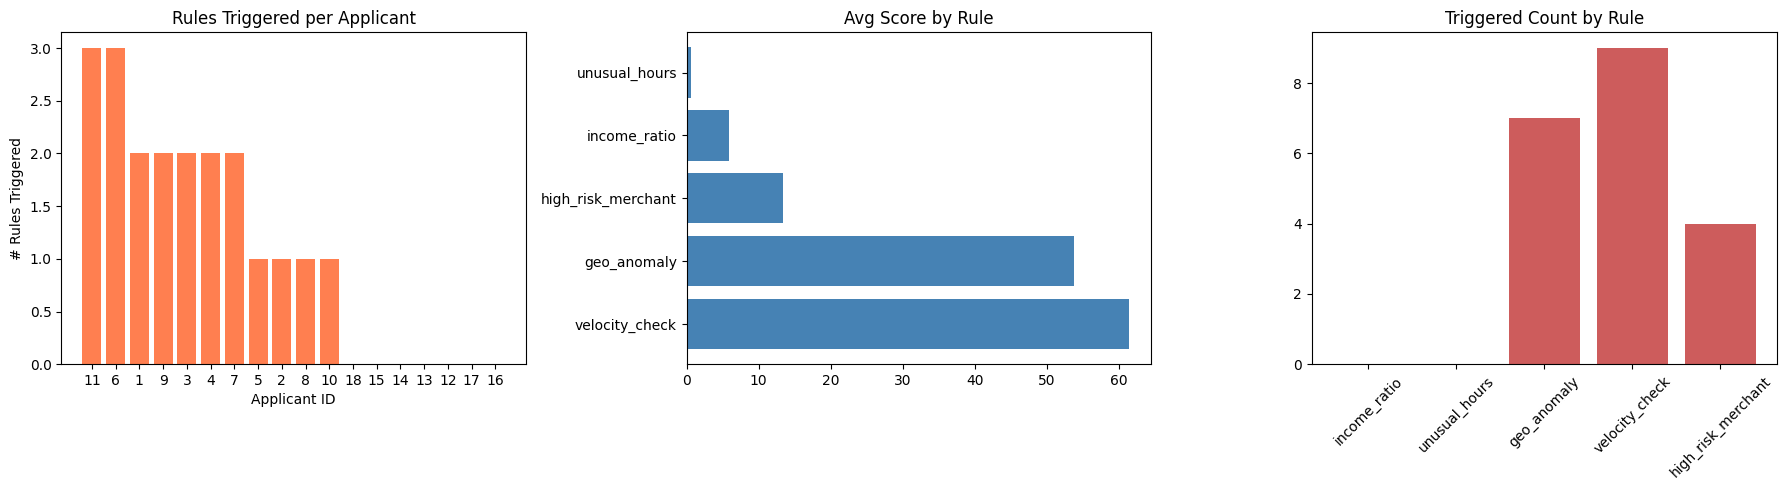

In [13]:
# visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. rules triggered per applicant
axes[0].bar(summary['application_id'].cast(str).to_list(), summary['rules_triggered'].to_list(), color='coral')
axes[0].set_title('Rules Triggered per Applicant')
axes[0].set_xlabel('Applicant ID')
axes[0].set_ylabel('# Rules Triggered')

# 2. avg score by rule
rule_scores = results.group_by('rule_name').agg(pl.col('score').mean().alias('avg_score')).sort('avg_score', descending=True)
axes[1].barh(rule_scores['rule_name'].to_list(), rule_scores['avg_score'].to_list(), color='steelblue')
axes[1].set_title('Avg Score by Rule')

# 3. triggered vs clean by rule
rule_triggered = results.group_by('rule_name').agg(pl.col('triggered').sum().alias('triggered_count'))
axes[2].bar(rule_triggered['rule_name'].to_list(), rule_triggered['triggered_count'].to_list(), color='indianred')
axes[2].set_title('Triggered Count by Rule')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# write results back to neon
# TODO: this should probably be in a pipeline not a notebook lol
import psycopg2.extras

cur = conn.cursor()
# clear old results first
cur.execute('DELETE FROM fraud_results')

for flag in fraud_flags:
    cur.execute(
        'INSERT INTO fraud_results (application_id, rule_name, triggered, score, details) VALUES (%s, %s, %s, %s, %s)',
        (flag['application_id'], flag['rule_name'], flag['triggered'], flag['score'], flag['details'])
    )

conn.commit()
print(f'Wrote {len(fraud_flags)} results to fraud_results table.')

# verify
cur.execute('SELECT COUNT(*) FROM fraud_results WHERE triggered = true')
print(f'Total triggered flags in DB: {cur.fetchone()[0]}')
cur.close()

Wrote 82 results to fraud_results table.
Total triggered flags in DB: 20


In [ ]:
# update application statuses based on fraud results
# if 2+ rules triggered -> rejected, otherwise -> approved
# this is pretty crude but whatever, it works for now

cur = conn.cursor()

for app_id in summary['application_id'].to_list():
    rules_triggered = summary.filter(pl.col('application_id') == app_id)['rules_triggered'][0]
    
    if rules_triggered >= 2:
        new_status = 'rejected'
    else:
        new_status = 'approved'
    
    cur.execute(
        'UPDATE credit_applications SET status = %s WHERE id = %s',
        (new_status, app_id)
    )
    print(f'Applicant {app_id}: {rules_triggered} rules triggered → {new_status}')

conn.commit()
cur.close()
print(f'\nDone. Updated {len(summary)} applications.')

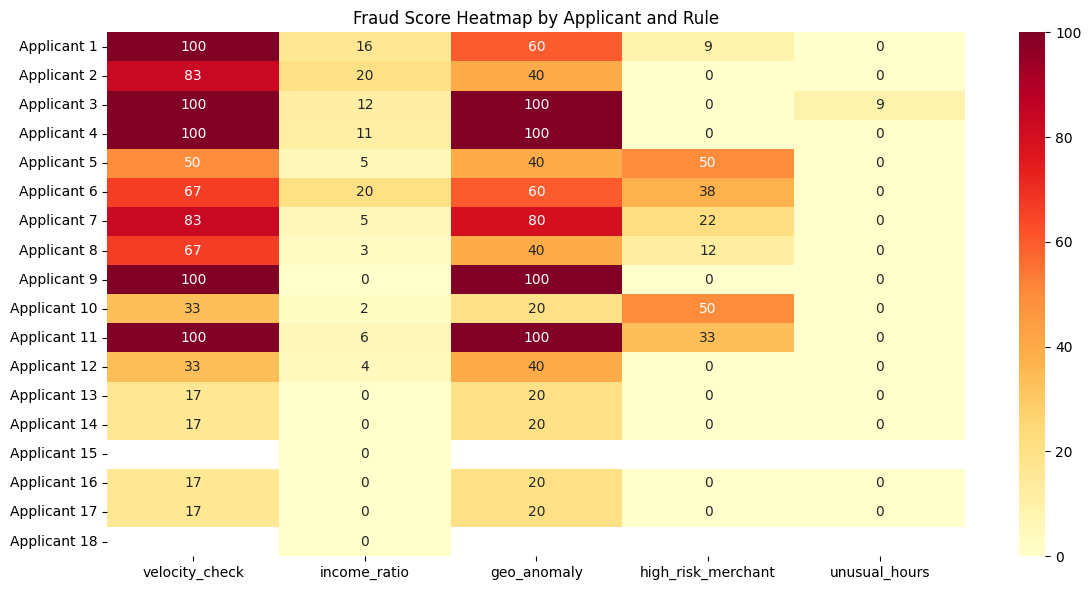

In [15]:
# heatmap of scores - this is useful for the compliance team
pivot_data = results.pivot(on='rule_name', index='application_id', values='score').sort('application_id')

# get just the numeric columns for the heatmap
rule_cols = [c for c in pivot_data.columns if c != 'application_id']
heatmap_data = pivot_data.select(rule_cols).to_numpy()
app_ids = pivot_data['application_id'].to_list()

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    xticklabels=rule_cols,
    yticklabels=[f'Applicant {i}' for i in app_ids],
    annot=True, fmt='.0f', cmap='YlOrRd', ax=ax
)
ax.set_title('Fraud Score Heatmap by Applicant and Rule')
plt.tight_layout()
plt.show()

In [16]:
conn.close()
print('done ✓')

done ✓
